# PCA — The Covariance Matrix

*Course notes for **Math for Machine Learning**, C1 · W4 · L2 · V07b — "PCA: Covariance Matrix" (DeepLearning.AI).*

All that variance and covariance leads to one object: the **covariance matrix** — a compact store of **every** pairwise relationship in the data. We cover:

- Its structure: **variances on the diagonal**, **covariances off-diagonal** (and it's symmetric).
- The elegant matrix formula $C = \frac{1}{n-1}(A - \mu)^T (A - \mu)$ and why it works.
- A worked example, and how it scales to any number of variables.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
%matplotlib inline

## 1. What the covariance matrix stores

Three datasets with roughly the **same** variances — $\mathrm{Var}(x) \approx 3$, $\mathrm{Var}(y) \approx 1$ — but different covariances: $-2$ (downward), $0$ (flat), $+2$ (upward). Each gets a covariance matrix with **variances on the diagonal** and **covariances off-diagonal**:

$$ \begin{pmatrix} 3 & -2 \\ -2 & 1 \end{pmatrix}, \qquad \begin{pmatrix} 3 & 0 \\ 0 & 1 \end{pmatrix}, \qquad \begin{pmatrix} 3 & 2 \\ 2 & 1 \end{pmatrix}. $$

Two facts: the covariance of a variable **with itself is its variance** ($\mathrm{Cov}(x,x)=\mathrm{Var}(x)$), and the matrix is **symmetric** since $\mathrm{Cov}(x,y)=\mathrm{Cov}(y,x)$.

In [2]:
for label, cov_xy in [('negative', -2), ('zero', 0), ('positive', 2)]:
    C = np.array([[3, cov_xy],
                  [cov_xy, 1]])
    print(f'{label} covariance:\n{C}\n')

negative covariance:
[[ 3 -2]
 [-2  1]]

zero covariance:
[[3 0]
 [0 1]]

positive covariance:
[[3 2]
 [2 1]]



## 2. The matrix formula

The whole matrix comes from one compact expression. Store the data in $A$ (each **row** an observation, each **column** a variable), and let $\mu$ be the same-shape matrix whose columns hold each variable's mean. Then

$$ \boxed{\; C = \frac{1}{n-1}\,(A - \mu)^T (A - \mu) \;} $$

**Shapes:** $(A-\mu)^T$ is $(\text{variables} \times n)$ and $(A-\mu)$ is $(n \times \text{variables})$, so the product is $(\text{variables} \times \text{variables})$ — exactly the covariance matrix's size.

Why it works, element by element:
- entry $(1,1)$: (row 1)$\cdot$(col 1) $= \sum_i (x_i - \mu_x)^2$, which over $n-1$ is $\mathrm{Var}(x)$;
- entry $(1,2)$: $\sum_i (x_i - \mu_x)(y_i - \mu_y)$, over $n-1$ is $\mathrm{Cov}(x,y)$;
- entries $(2,1)$ and $(2,2)$ give $\mathrm{Cov}(y,x)$ and $\mathrm{Var}(y)$.

In [3]:
def covariance_matrix(A):
    n = A.shape[0]
    mu = A.mean(axis=0)              # column means (one per variable)
    centered = A - mu               # broadcasts: A - mu
    return (centered.T @ centered) / (n - 1)

## 3. A worked example

Eight observations with a **downward** trend — so we expect similar $x$ and $y$ variances and a **negative** covariance. The column means are $\mu_x = 8$, $\mu_y = 6$. Subtract them (forming $A - \mu$), then apply $\frac{1}{n-1}(A-\mu)^T(A-\mu)$ with $n-1 = 7$.

*(The eight points are reconstructed to have means $(8,6)$ and a downward trend, matching the lecture's description.)*

In [4]:
A = np.array([[ 5, 8],
              [ 6, 8],
              [ 7, 7],
              [ 8, 6],
              [ 8, 6],
              [ 9, 5],
              [10, 4],
              [11, 4]])   # 8 observations, 2 features

print('means (mu_x, mu_y) =', A.mean(axis=0))   # (8, 6)
C = covariance_matrix(A)
print('covariance matrix C =')
print(C)
print()
print('matches np.cov:', np.allclose(C, np.cov(A.T, ddof=1)))
print('-> similar variances on the diagonal, negative covariance off-diagonal')

means (mu_x, mu_y) = [8. 6.]
covariance matrix C =
[[ 4.    -3.143]
 [-3.143  2.571]]

matches np.cov: True
-> similar variances on the diagonal, negative covariance off-diagonal


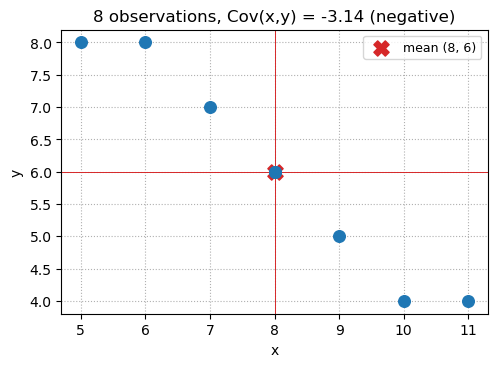

In [5]:
# Visualize the data with its mean and trend
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(A[:, 0], A[:, 1], s=70, color='C0', zorder=5)
ax.scatter(*A.mean(axis=0), color='C3', s=120, marker='X', label='mean (8, 6)')
ax.axvline(8, color='C3', lw=0.7); ax.axhline(6, color='C3', lw=0.7)
ax.set_aspect('equal'); ax.grid(True, ls=':'); ax.legend(fontsize=9)
ax.set_title(f'8 observations, Cov(x,y) = {C[0,1]:.2f} (negative)')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.show()

## 4. It scales to any number of variables

The **exact same formula** works for any dataset. Add a third feature $z$, and $A$ becomes $n \times 3$; then $\frac{1}{n-1}(A-\mu)^T(A-\mu)$ is a $3 \times 3$ covariance matrix — variances on the diagonal, all pairwise covariances off it. In general $d$ features give a $d \times d$ covariance matrix.

In [6]:
A3 = np.array([[ 5, 8, 2],
               [ 6, 8, 3],
               [ 7, 7, 3],
               [ 8, 6, 5],
               [ 8, 6, 6],
               [ 9, 5, 6],
               [10, 4, 8],
               [11, 4, 9]])   # now 3 features: x, y, z

C3 = covariance_matrix(A3)
print('3 x 3 covariance matrix:')
print(C3)
print('symmetric:', np.allclose(C3, C3.T))

3 x 3 covariance matrix:
[[ 4.    -3.143  4.857]
 [-3.143  2.571 -3.857]
 [ 4.857 -3.857  6.214]]
symmetric: True


## Summary

- The **covariance matrix** compactly stores every pairwise relationship: **variances on the diagonal**, **covariances off-diagonal**; it is **symmetric** because $\mathrm{Cov}(x,y)=\mathrm{Cov}(y,x)$, and $\mathrm{Cov}(x,x)=\mathrm{Var}(x)$.
- It has a clean matrix form: $C = \frac{1}{n-1}(A-\mu)^T(A-\mu)$, where $A$ has observations in rows and variables in columns — the multiplication reproduces exactly the per-element variance/covariance formulas.
- The formula works for **any** number of variables: $d$ features $\Rightarrow$ a $d \times d$ covariance matrix. In NumPy: `np.cov(A.T, ddof=1)`.
- This matrix is the object whose **eigenvectors** power the final step of PCA — coming next.